[Week 1](#Week-1) | [weeks 2,3](#Weeks-2,-3) | [Week 4](#Week-4)

---

# Week 1

Contents:

[1. Advanced Linear Algebra](#1.-Advanced-Linear-Algebra)

* [1.1. Singular Value Decomposition (SVD)](#1.1.-Singular-Value-Decomposition-(SVD))

* [1.2. Condition Number](#1.2.-Condition-Number)

* [1.3. The Moore-Penrose Pseudoinverse](#1.3.-The-Moore-Penrose-Pseudoinverse)

* [1.4. Least Squares System](#1.4.-Least-Squares-System)

[2. Vector-Matrix Gradients](#2.-Vector-Matrix-Gradients)

* [2.1. Gradient with Respect to a Vector](#2.1.-Gradient-with-Respect-to-a-Vector)

* [2.2. Gradient with Respect to a Matrix](#2.2.-Gradient-with-Respect-to-a-Matrix)

* [2.3. Hessian Matrix](#2.3.-Hessian-Matrix)

[3. Gradient Flow](#3.-Gradient-Flow)

---

In [192]:
import numpy as np
from scipy import linalg
from scipy.linalg import pinv
from scipy.linalg import lstsq

---

## 1. Advanced Linear Algebra

Linear algebra is a branch of mathematics that is widely used throughout science and engineering.                                                

A good understanding of linear algebra is essential for understanding and working
with many machine learning and deep learning algorithms.                             
            
We therefore precede our introduction to deep learning with a focused presentation of the key linear algebra prerequisites.

---

### 1.1. Singular Value Decomposition (SVD)

The SVD provides a way to factorize a matrix, into singular vectors and singular values.                                         

Every real matrix has a SVD.

We can write a matrix $A$ as a product of three matrices:

$A=UDV^T$

Suppose $A$ is an $m×n$ matrix. Then $U$ is defined to be an $m×m$, $D$ an $m×n$ , and $V$ an $n×n$ matrix.

The matrices $U$ and $V$ are both defined to be orthogonal matrices.                                            
The matrix $D$ is defined to be a diagonal matrix (not necessarily square).

The elements along the diagonal of $D$ are known as the singular values of the matrix $A$.                                         
The columns of $U$ are known as the left-singular vectors and columns of $V$ are known as the right-singular vectors.

In [193]:
A = np.array([[18, -9, 3, -2],
              [-4, 15, 6, 25],
              [1, -8, 12, -7]])

print(f'A:\n{A}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]


In [194]:
U, s, Vt = linalg.svd(A)

In [195]:
print(f'U:\n{U}')
print(f'\nSingular values:\n{s}')
print(f'\nVt:\n{Vt}')

U:
[[ 0.37767695 -0.85883285 -0.34607263]
 [-0.87451582 -0.45367142  0.17147688]
 [ 0.30427324 -0.23788312  0.92240415]]

Singular values:
[32.92715826 18.18042883 12.77788153]

Vt:
[[ 0.32193855 -0.57554362 -0.01405482 -0.75160334]
 [-0.76357873  0.15552379 -0.44845612 -0.43777504]
 [-0.46899876 -0.13244969  0.86551853 -0.11564999]
 [-0.30552129 -0.7918453  -0.22263704  0.47965666]]


In [196]:
D = np.zeros((U.shape[0], Vt.shape[0]))

D[:len(s), :len(s)] = np.diag(s)

print(f'D:\n{D}')

D:
[[32.92715826  0.          0.          0.        ]
 [ 0.         18.18042883  0.          0.        ]
 [ 0.          0.         12.77788153  0.        ]]


In [197]:
A_svd = U @ D @ Vt

print(f'A:\n{A}')
print(f'\nA_svd:\n{A_svd}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]

A_svd:
[[18. -9.  3. -2.]
 [-4. 15.  6. 25.]
 [ 1. -8. 12. -7.]]


---

### 1.2. Condition Number

The condition number of a matrix measures how sensitive a linear system is to small changes in the input.

For a matrix $A$, it tells you how much errors in $b$ or numerical rounding can be amplified when solving:

$Ax = b$

We can use SVD of $A$ and define condition number as follows:

$κ(A) = \frac{σ_{max}}{σ_{min}}$

where:

$σ_{max}$ = largest singular value                                                          
$σ_{min}$ = smallest nonzero singular value

In [198]:
print(f'A:\n{A}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]


In [199]:
print(f'Singular values:\n{s}')

Singular values:
[32.92715826 18.18042883 12.77788153]


In [200]:
cond_num = s[0] / s[-1]
print(f'condition number = {cond_num}')

condition number = 2.5768871142558845


confirm the solution

In [201]:
cond = np.linalg.cond(A)
print(f'condition number = {cond}')

condition number = 2.5768871142558845


---

### 1.3. The Moore-Penrose Pseudoinverse

Matrix inversion is not defined for matrices that are not square or singular. so the Moore-Penrose pseudoinverse allows us to make some headway in this case.

The pseudoinverse of $A$ is defined as a matrix

$A^+ = VD^+U^T$

Where $U$, $D$ and $V$ are the singular value decomposition of $A$.                                               
The pseudoinverse $D^+$ of a diagonal matrix $D$ is obtained by taking the reciprocal of its non-zero elements then taking the transpose of the resulting matrix.

In [202]:
print(f'A:\n{A}')

A:
[[18 -9  3 -2]
 [-4 15  6 25]
 [ 1 -8 12 -7]]


In [203]:
V = Vt.T
print(f'V:\n{V}')

V:
[[ 0.32193855 -0.76357873 -0.46899876 -0.30552129]
 [-0.57554362  0.15552379 -0.13244969 -0.7918453 ]
 [-0.01405482 -0.44845612  0.86551853 -0.22263704]
 [-0.75160334 -0.43777504 -0.11564999  0.47965666]]


In [204]:
Ut = U.T
print(f'Ut:\n{Ut}')

Ut:
[[ 0.37767695 -0.87451582  0.30427324]
 [-0.85883285 -0.45367142 -0.23788312]
 [-0.34607263  0.17147688  0.92240415]]


In [205]:
D_plus = np.zeros((V.shape[0], Ut.shape[0]))

D_plus[:len(s), :len(s)] = np.diag(1/s)

print(f'D_plus:\n{D_plus}')

D_plus:
[[0.03037007 0.         0.        ]
 [0.         0.0550042  0.        ]
 [0.         0.         0.07826023]
 [0.         0.         0.        ]]


In [206]:
A_plus = V @ D_plus @ Ut

print(f'A_plus:\n{A_plus}')

A_plus:
[[ 0.05246591  0.00420994 -0.02088981]
 [-0.01036115  0.00962756 -0.01691467]
 [-0.00241787  0.02317909  0.06821765]
 [ 0.01519152  0.02933408 -0.00956581]]


Confirm the solution

In [207]:
A_pinv = pinv(A)

print(A_pinv)

[[ 0.05246591  0.00420994 -0.02088981]
 [-0.01036115  0.00962756 -0.01691467]
 [-0.00241787  0.02317909  0.06821765]
 [ 0.01519152  0.02933408 -0.00956581]]


---

### 1.4. Least Squares System

Suppose we want to find the value of $x$ that minimizes

$f(x) = \frac{1}{2}||Ax-b||_{2}^{2}$

There are specialized linear algebra algorithms that can solve this problem efficiently.   

However, we can use the Moore-Penrose pseudoinverse:

$x=A^+b$

Now we want to find the least squares solution for the following system:

$-7x_1+2x_2=-11$                                                    
$16x_1-10x_2=-3$                                                   
$5x_1+8x_2=6$

In [208]:
A = np.array([
    [-7, 2],
    [16, -10],
    [5, 8]
])

b = np.array([-11, -3, 6])

print(f"A:\n{A}")
print(f"\nb: {b}")

A:
[[ -7   2]
 [ 16 -10]
 [  5   8]]

b: [-11  -3   6]


In [209]:
x = pinv(A) @ b

print(f"x: {x}")

x: [0.46462491 0.70392701]


confirm the soultion

In [210]:
x_lstsq = lstsq(A, b)

print(f"x_lstsq: {x_lstsq[0]}")

x_lstsq: [0.46462491 0.70392701]


---

## 2. Vector-Matrix Gradients

Most deep learning algorithms involve optimization of some sort, the task of either minimizing or maximizing some function $f(x)$ by altering $x$.                                                                                           

The function we want to minimize or maximize is called the **objective function**, a function combining of a one or some loss functions and some terms.

We often denote the value that minimizes or maximizes a function with a superscript ∗ 

$x^* = argmin f(x)$

Suppose we have a function $y = f(x)$, where both $x$ and $y$ are real numbers.
The **derivative** of this function is denoted as $f'(x)$ or as $\frac{dy}{dx}$.                                              
It is useful for minimizing a function because it tells us how to change $x$ in order to make a small improvement in $y$.

We can reduce f(x) by moving x in small steps with opposite sign of the derivative.
This technique is called **gradient descent**.

Points where $f'(x) = 0$ are known as **critical points**.                                 
                                                    
A **local minimum** is a point where $f(x)$ is lower than at all neighboring points.                                           
Some critical points are neither maxima nor minima. These are known as **saddle points**.                                      
A point that obtains the absolute lowest value of $f(x)$ is a **global minimum**.

---

### 2.1 Gradient with Respect to a Vector

For functions with multiple inputs, we must make use of the concept of **partial derivatives**.                           

The partial derivative **$\frac{∂f(x)}{∂x_i}$** measures how $f$ changes as only the variable $x_i$ increases at point $x$.                                           

The **gradient** generalizes the notion of derivative to the case where the derivative is with respect to a vector: the gradient of $f$ is the
vector containing all of the partial derivatives, denoted **$∇f(x)$**.                                         

Element $i$ of the gradient is the partial derivative of $f$ with respect to $x_i$. In multiple dimensions, critical points are points where every element of the gradient is equal to zero.

**Example**

consider the following function:

$f(x_1,x_2)=x_1^2+3x_1x_2+x_2^2$

In [211]:
def f(x):
    return x[0]**2 + 3*x[0]*x[1] + x[1]**2

In [212]:
x = [2.0, 5.0]
f(x)

59.0

The gradient is

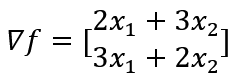

Analytical Gradient

In [213]:
def grad_anlytc(x):
    return np.array([
        2*x[0] + 3*x[1],
        3*x[0] + 2*x[1]
    ])

In [214]:
print("Analytical:\n",grad_anlytc(x))

Analytical:
 [19. 16.]


Numerical Gradient

For the $i$-th component:

$\frac{∂f}{∂x_i}≈\frac{f(x+he_i)-f(x-he_i)}{2h}$

Where $h ≈ 10^{-5}$ and $e_i$ is the $i$-th standard basis vector (e.g. $e_3$ = [0,0,1,0])

In [215]:
def grad_num(x, h=1e-5):
    
    g = np.zeros_like(x)
    for i in range(len(x)):
        x1 = x.copy()
        x2 = x.copy()
        x1[i] += h
        x2[i] -= h
        g[i] = (f(x1)-f(x2))/(2*h)

    return g

In [216]:
print("Numerical:\n",grad_num(x))

Numerical:
 [19. 16.]


---

### 2.2. Gradient with Respect to a Matrix

Consider

$f(X) = ||X||_F^2$

where

$||X||_F^2 = \sum_{i,j}X^2_{i,j}$

In [217]:
X = np.array([
    [7., 2.],
    [4., 6.]
])

print('X:\n',X)

X:
 [[7. 2.]
 [4. 6.]]


In [218]:
def f(X):
    return np.sum(X**2)

print(f(X))

105.0


Analytical Gradient is as follows:

$∇_Xf=2X$

In [219]:
def grad_analytic(X):
    return 2 * X

print("Analytical:\n",grad_analytic(X))

Analytical:
 [[14.  4.]
 [ 8. 12.]]


Numerical Gradient is similar as we saw before:

$\frac{∂f}{∂X_{ij}}≈\frac{f(X+hE_{ij})-f(X-hE_{ij})}{2h}$

where:                                      

$E_{ij}$ is a matrix of the same size as $X$ that contains a 1 at position $(i,j)$ and 0 elsewhere.

In [ ]:
def grad_numeric(X, h=1e-5):
    
    G = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            X_plus = X.copy()
            X_minus = X.copy()
    
            X_plus[i, j] += h
            X_minus[i, j] -= h
            
            G[i, j] = (f(X_plus) - f(X_minus)) / (2 * h)

    return G

print("Numerical:\n",grad_numeric(X))

Numerical:
 [[14.  4.]
 [ 8. 12.]]


---

### 2.3. Hessian Matrix

When our function has multiple input dimensions, there are many second derivatives.                                     

These derivatives can be collected together into a matrix called the **Hessian matrix**.                                        

The Hessian matrix is defined such that

$H(f)(x)_{i,j} = \frac{∂^2}{∂x_i∂x_j}f(x)$

The second derivative can be used to determine whether a critical point is a local maximum, a local minimum, or saddle point.                                                     

When the second derivative $f"(x) > 0$, the first derivative $f'(x)$ increases as we move to the right and decreases as we move to the left.

Thus, when $f'(x) = 0$ and $f"(x) > 0$, we can conclude that $x$ is a local minimum.                                                                
This is known as the **second derivative test**.                                       
However, when $f"(x) = 0$, the test is inconclusive. In this case $x$ may be a saddle point, or a part of a flat region.

The Hessian plays the role of the second derivative to classify a critical point.

If $∇f(x) = 0$ (a critical point):

Positive Definite Hessian ($λ_i>0$ for all eigenvalues) ⇒ local minimum.                                  
Negative Definite Hessian ($λ_i<0$ for all eigenvalues) ⇒ local maximum.                                         
Indefinite Hessian (has both positive and negative eigenvalues) ⇒ saddle point.                                
singular or semidefinite Hessian  ⇒ test is inconclusive.                                        

Suppose we have the following function:

$f(x_1,x_2)=3x_1^2+4x_1x_2+4x_2^2$

The gradient is

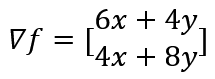

and

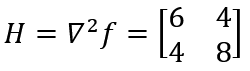

In [221]:
H = np.array([
    [6, 4],
    [4, 8]
])

Now we compute the eigenvalues of $H$

In [222]:
eigenvalues = np.linalg.eigvals(H)
print(eigenvalues)

[ 2.87689437 11.12310563]


So $H$ is Positive Definite and if $x^∗$ is a critical point of the function then it is a local minimum.

---

## 3. Gradient Flow

Gradient Flow is the continuous-time version of Gradient Descent.

Suppose we want to minimize a function $f(x)$.

In gradient descent, we update the parameter according to

$x_{k+1} = x_k-η∇f(x_k)$

where

$η$ is the learning rate (step size)

If we take smaller and smaller steps ($η→0$), 

Then the discrete update rule becomes a continuous differential equation:

$\frac{dx}{dt}=-∇f(x)$

This equation is called the **gradient flow** of f.

**Example**

Consider the following function:

$f(x)=x^2$

Its gradient is

$∇f(x)=2x$

The gradient flow equation becomes

$\frac{dx}{dt}=-2x$

The solution is

$x(t)=x_0e^{-2t}$

As $t → ∞$

$x(t) → 0$

which is exactly the minimum of $f(x)$.

---

---

# Weeks 2, 3

Contents:

[1. SVD instead of GAP?](#1.-SVD-instead-of-GAP?)

[2. Gradient Descent vs Gradient Flow](#2.-Gradient-Descent-vs-Gradient-Flow)

[3. Spectral Theory](#3.-Spectral-Theory)

[4. Jacobian Theory](#4.-Jacobian-Theory)

[5. Chain Rule in Computational Graph](#5.-Chain-Rule-in-Computational-Graph)

[6. Taylor Expansion](#6.-Taylor-Expansion)

[7. Taylor Expansion & Curvature](#7.-Taylor-Expansion-&-Curvature)

[8. Vanishing/Exploding Gradient](#8.-Vanishing/Exploding-Gradient)

[9. How To Import Our Modules](#9.-How-To-Import-Our-Modules)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import svd

---

## 1. SVD instead of GAP?

In CNN, after stacking several convolution layers we need to **flatten** the feature maps to classify the input. instead of flattening, we can calculate the **average** of each channel and put them in an array which is called **Global average pooling (GAP)**. This reduces the number of parameters and also helps prevent overfitting.

Suppose the final feature maps are $256×256×64$.                                           
The output size of Flatten is $256×256×64 = 4,194,304$ features but GAP is just $64$ features!

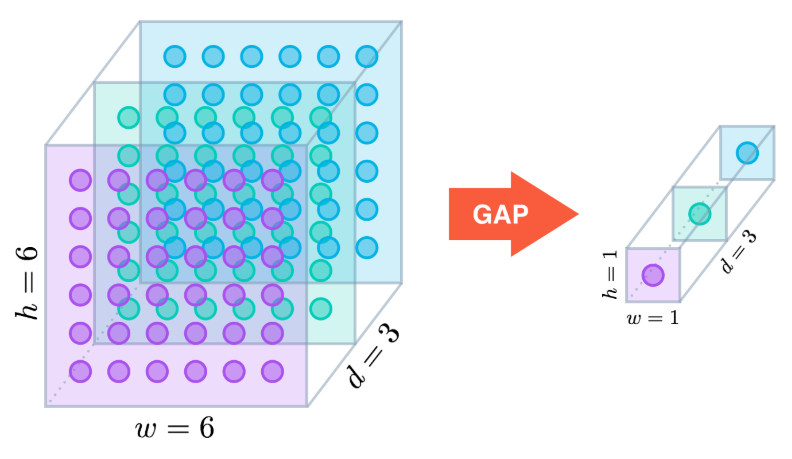

The architecture of the model is like the following

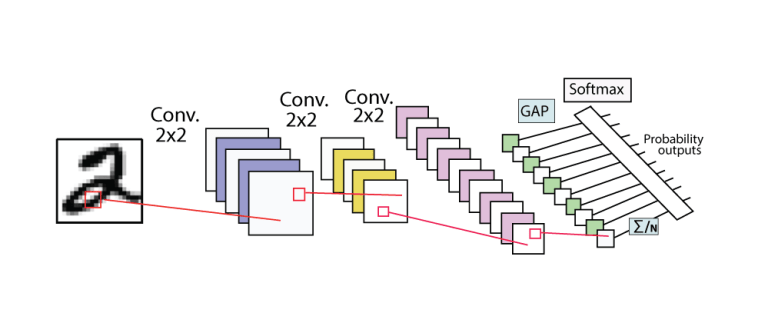

**SVD** is a technique to decompose or approximate a matrix to extract essential information which is explained in the previous week.

Another approach alternative to flattening is using **singular values/vectors** of the feature maps.

It is basically robust to **noise** due to the nature of SVD and also shown that it provides about 36% better performance than **global average pooling** and effective in **knowledge distillation** such that the performance of a student network can be improved by about 1.7% for the CIFAR100 dataset.

Now lets implement them

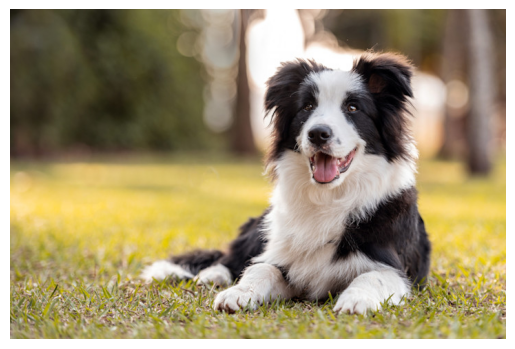

In [2]:
img = plt.imread('C:/Users/Ali/Desktop/Dog.jpg')

plt.imshow(img)
plt.axis("off");

In [3]:
(h, w, c) = img.shape

print(f'Height = {h}\nWidth = {w}\nChannels = {c}')

Height = 479
Width = 720
Channels = 3


1. Flattening

In [ ]:
def Flat(img):
    return img.flatten()

flat = Flat(img)

print('Flattened =', flat)
print('Shape =', flat.shape)

Flattened = [ 26  23  16 ... 167 162  58]
Shape = (1034640,)


Its shape is $H×W×C$

In [21]:
h * w * c

1034640

2. GAP

In [66]:
def GAP(img):
    
    c = img.shape[2]
    gap = np.empty([c])
    
    for i in range(c):
        mean = np.mean(img[:,:,i])
        gap[i] = mean
        
    return gap
    
    
gap = GAP(img)

print('GAP =', gap)
print('Shape =', gap.shape)

GAP = [150.65759974 136.27645268  99.20447692]
Shape = (3,)


3. SVD

There are three options:                                              
Option A) we can't apply SVD on a tensor, so we reshape it to become a matrix then keep the first column of $V$.

In [27]:
img_resh = img.reshape(h*w, c)
img_resh

array([[ 26,  23,  16],
       [ 27,  24,  17],
       [ 28,  25,  16],
       ...,
       [156, 147,  78],
       [163, 156,  68],
       [167, 162,  58]], shape=(344880, 3), dtype=uint8)

In [61]:
def SVD_A(img):
    
    (h, w, c) = img.shape
    img_resh = img.reshape(h*w, c)
    
    U_1, S_1, VT_1 = svd(img_resh, full_matrices=False)
    
    return VT_1[0]


V1 = SVD_A(img)

print('V_1 =', V1)
print('Shape =', V1.shape)

V_1 = [-0.66056999 -0.60235691 -0.44812212]
Shape = (3,)


Option B) SVD per channel then keep the largest singular value.

In [67]:
def SVD_B(img):
    
    c = img.shape[2]
    s_values = np.empty([c])
    
    for i in range(c):
        U_2, S_2, VT_2 = svd(img[:, :, i], full_matrices=False) 
        s_values[i] = S_2[0]
        
    return s_values
    
    
s_val = SVD_B(img)

print('Singular Values =', s_val)
print('Shape =', s_val.shape)

Singular Values = [91750.74120999 82917.73742007 60989.3597589 ]
Shape = (3,)


Option C) SVD per channel then keep the first left/right singular vector.

In [70]:
def SVD_C(img):
    
    h, w, c = img.shape
    s_vector = np.empty((c, w))

    for i in range(c):
        U_3, S_3, VT_3 = svd(img[:, :, i], full_matrices=False)
        s_vector[i] = VT_3[0]

    return s_vector.flatten()


s_vec = SVD_C(img)

print('Right singular vectors =', s_vec)
print('Shape', s_vec.shape)

Right singular vectors = [0.03176311 0.03198126 0.03248961 ... 0.03245728 0.03271257 0.03223747]
Shape (2160,)


---

## 2. Gradient Descent vs Gradient Flow

**Gradient Descent** is a **discrete**-time optimization algorithm, whereas **Gradient Flow** is its **continuous**-time counterpart.

Both aim to minimize a loss function by updating model parameters in the direction of the negative gradient. 

Gradient Descent updates parameters at discrete iterations, while Gradient Flow models parameter evolution continuously over time.

Gradient Flow is mainly used for **theoretical analysis** of optimization dynamics, convergence, and loss evolution.

For sequence models such as RNNs used in time-series and text processing, the data evolve over time, but the training algorithm is still Gradient Descent. Gradient Flow is a continuous mathematical model that helps analyze how the model parameters and loss evolve during optimization.

Now we define a function and find its minimum using gradient flow.

$f(x)=x^{2}$

In [ ]:
def f(x):
    return x**2

$\nabla f(x) = 2x$

In [ ]:
def grad_f(x):
    return 2 * x

$\frac{dx}{dt} = -\nabla f(x) = -2x$

The numerical approximation (Euler method) of the above is

$\frac{dx}{dt}​≈\frac{x_{n+1}​−x_n}{Δt}$

so we have

$x_{n+1}​=x_n​−Δt(2x_n​)$

In [66]:
def gradient_flow(x0, delta_t=0.01, T=5):
    t = np.arange(0, T+delta_t, delta_t)
    x = np.zeros(len(t))
    x[0] = x0
    for i in range(len(t) - 1):
        x[i+1] = x[i] - delta_t * grad_f(x[i])
    return t, x

x0 = 10
t, x = gradient_flow(x0)

print("Final x =", x[-1])
print("Final f(x) =", f(x[-1]))

Final x = 0.00041023985145472635
Final f(x) = 1.6829673572159595e-07


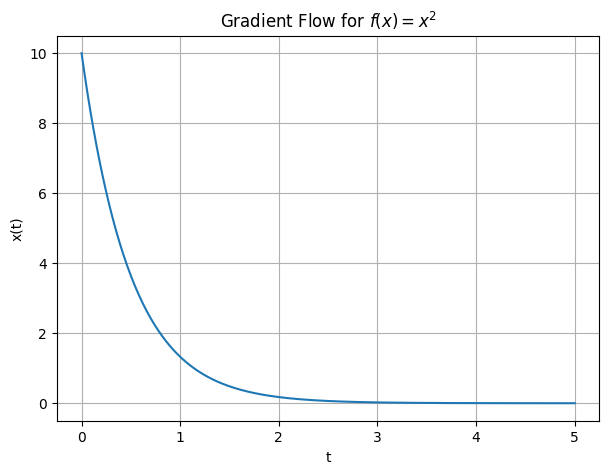

In [67]:
plt.figure(figsize=(7, 5))
plt.plot(t, x)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Gradient Flow for $f(x)=x^2$")
plt.grid(True)
plt.show()

---

## 3. Spectral Theory

Spectral Theory appears through the study of **eigenvalues**, **eigenvectors**, **singular values**, and **matrix decompositions**.                  

Although the underlying mathematics comes from functional analysis, most applications involve matrices and finite-dimensional operators.                         

The spectrum of a linear operator (or matrix) is a generalization of the idea of eigenvalues.

Applications: 
                                    
SVD                                                 
PCA                                                     
Spectral Clustering                                          
Graph Neural Networks                                                
Optimization and Hessian Spectrum , ...                                                                                        

We saw SVD and Hessian matrix in week 1.

Now we are going to explain PCA.

### 3.1 Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that finds the directions of maximum variance in data by computing the eigenvalues and eigenvectors of the covariance matrix and uses those directions to represent the data in fewer dimensions with minimal loss of information.

In [131]:
# sample data

X = pd.DataFrame({
    'feature 1': [1, 2, 3, 4],
    'feature 2': [2, 4, 6, 8],
    'feature 3': [15, 18, 13, 11]
})

display(X)

,feature 1,feature 2,feature 3
0,1,2,15
1,2,4,18
2,3,6,13
3,4,8,11


We center the data because PCA is based on the covariance matrix, which measures variation around the mean.

In [134]:
X_centered = X - np.mean(X, axis=0)

print("Centered X:")
display(X_centered)

Centered X:


,feature 1,feature 2,feature 3
0,-1.5,-3.0,0.75
1,-0.5,-1.0,3.75
2,0.5,1.0,-1.25
3,1.5,3.0,-3.25


Compute the covariance matrix:

$C = \frac{1}{n}X^{T}X$

In [126]:
n = X_centered.shape[1]
cov_matrix = (1/n) * (X_centered.T @ X_centered)

print("Covariance matrix:")
display(cov_matrix)

Covariance matrix:


,feature 1,feature 2,feature 3
feature 1,1.666667,3.333333,-2.833333
feature 2,3.333333,6.666667,-5.666667
feature 3,-2.833333,-5.666667,8.916667


Eigenvalue decomposition:

$C=QVQ^T$

In [127]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n",eigenvalues)
print("\nEigenvectors:\n",eigenvectors)

Eigenvalues:
 [1.49672361e+01 9.99580934e-17 2.28276393e+00]

Eigenvectors:
 [[-3.08870849e-01 -8.94427191e-01  3.23417375e-01]
 [-6.17741698e-01  4.47213595e-01  6.46834751e-01]
 [ 7.23183236e-01 -1.11019660e-16  6.90656215e-01]]


In [128]:
# sort eigenvalues and eigenvectors
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# select top k eigenvectors
k = 2
W = eigenvectors[:, :k]

print('W:\n',W)

W:
 [[-0.30887085  0.32341738]
 [-0.6177417   0.64683475]
 [ 0.72318324  0.69065621]]


Transform data:

$T = XW$

In [129]:
X_pca = X_centered @ W

print("Transformed data:\n",X_pca)

Transformed data:
           0         1
0  2.858919 -1.907638
1  3.484114  1.781417
2 -1.676156 -0.054777
3 -4.666877  0.180998


---

## 4. Jacobian Theory

Sometimes we need to find all of the partial derivatives of a function whose input
and output are both vectors.

The matrix containing all such partial derivatives is
known as a **Jacobian matrix**. 

Specifically, if we have a function $f : R^m → R^n$,
then the Jacobian matrix $J ∈ R^{n×m}$ of $f$ is defined such that $J_{i,j} = \frac{∂}{∂xj}f(x)_i$.

In deep learning it describes how the outputs of a neural network change with respect to its inputs or parameters.

It is fundamental to backpropagation, sensitivity analysis, understanding stability,...

Suppose a neural network maps an input vector $x∈R^n$ to an output vector $y=f(x)∈R^m$:

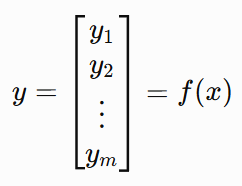

Then the Jacobian matrix is

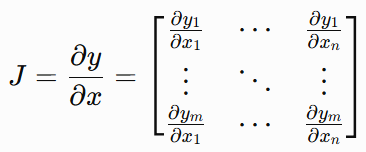

where each element tells us:

"How much does output $y_i$ change when input $x_j$ changes?"

**Example**

Consider

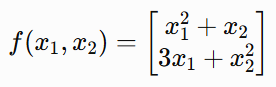

In [6]:
def func(x_1, x_2):
    return np.array([
        x_1^2 + x_2,
        3*x_1 + x_2^2
        ])

Then

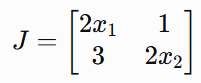

In [7]:
def J(x_1, x_2):
    return np.array([
        [2*x_1, 1],
        [3, 2*x_2]
        ])

At point (1, 2) we have:

In [8]:
J(1, 2)

array([[2, 1],
       [3, 4]])

Interpretation:                                                              
Increasing $x_1$ changes output 1 twice.                                                
Increasing $x_2$ changes output 2 four times.

We see one of the application of Jacobians in the next section.

---

## 5. Chain Rule in Computational Graph

During training, **Forward Propagation** continues onward until it produces a scalar cost $J(θ)$.

The **Back-Propagation** algorithm allows the information from the cost to then flow backwards through
the network, in order to compute the gradient.                                        
The
idea of computing derivatives by propagating information through a network is
very general, and can be used to compute values such as the **Jacobian** of a function
$f$ with multiple outputs.                                        

To describe the back-propagation algorithm more precisely, it is helpful to have a **Computational Graph** language.                                         
It is a graphical representation of a mathematical computation so that we can compute the output value (forward pass) and the gradients (backward pass) where                                       
**Nodes** represent variables that may be a scalar, vector, matrix, tensor or operations (like +, ×, sin, etc.)                                  
**Edges** represent the flow of data and dependencies between operations.

**Chain Rule** is used to compute the derivatives of functions formed by composing other functions
whose derivatives are known. Back-propagation is an algorithm that computes the
chain rule, with a specific order of operations that is highly efficient.

Suppose a network has $L$ layers:                                   

$a^{(l)}=f(z^{(l)})$ 

$z^{(l)}=W^{(l)}a^{(l−1)}+b^{(l)}$

And the loss function is $J$.

To compute the gradient for layer $l$ using chain rule, we have:

$\frac{∂J}{∂W^{(l)}}=\frac{∂J}{∂a^{(L)}}\frac{∂a^{(L)}}{∂a^{(L−1)}}⋯\frac{∂a^{(l)}}{∂W^{(l)}}$

**Example**

$f(x,y,z)=(x+2y)⋅z$

Forward pass: 
                                                                            
$q=x+2y$                                      
$f=q⋅z$

Backward pass:

$\frac {∂f}{∂q}​=z$, $\frac {∂f}{∂z}​=q$ 

$\frac {∂q}{∂x}​=1$, $\frac {∂q}{∂y}​=2$

Now chain rule shows up:

$\frac {∂f}{∂x}​ = \frac {∂f}{∂q} ​⋅ \frac {∂q}{∂x} = 1.z​ = z$

$\frac {∂f}{∂y}​ = \frac {∂f}{∂q} ​⋅ \frac {∂q}{∂y}​ = 2.z = 2z$

So if:

$a→b→c$

Then:

$\frac{∂c}{∂a}=\frac{∂c}{∂b}⋅\frac{∂b}{∂a}$

If there are multiple paths, we sum over all paths.

---

## 6. Taylor Expansion

**Taylor expansion (Taylor series)** expresses a function as an infinite polynomial around a point a.

The Taylor expansion of $f:R→R$ about $x=a$ is

$f(x)=f(a)+f'(a)(x−a)+\frac{f''(a)}{2!}​(x−a)^2+\frac{f'''(a)}{3!}​(x−a)^3+⋯=∑_{n=0}^{∞}​\frac{f^{(n)}(a)}{n!}​(x−a)^n$

Sometimes there is no exact series for the function so we can **approximate** it using its available second (third,...) derivatives:

$f(x)≈f(a)+f'(a)(x−a)+\frac{f''(a)}{2!}​(x−a)^2+\frac{f'''(a)}{3!}​(x−a)^3$

**Example**

$f(x) = (1-x)^3$ and $a=0$

The Taylor series is

$f(x) = (1-0)^3 -3(1-0)^{2}(x-0) + \frac{6(1-0)}{2!}(x-0)^{2} -\frac{6}{3!}(x-0)^3$

$f(x) = 1-3x+3x^2-x^3$

Now we plot the function, its Taylor expansion and approximations.

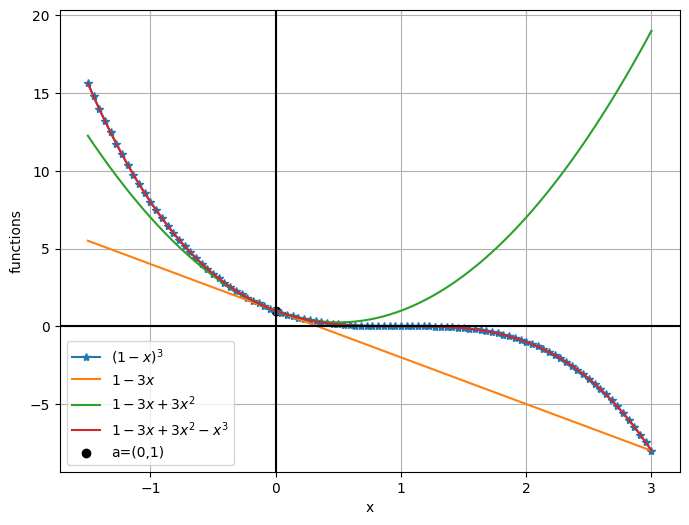

In [44]:
x = np.linspace(-1.5, 3, 100)
y = (1-x)**3
y1 = 1-3*x
y2 = 1-3*x+3*x**2
y3 = 1-3*x+3*x**2-x**3

plt.figure(figsize=(8, 6))
plt.plot(x, y, '-*', label='$(1-x)^3$')
plt.plot(x, y1, label='$1-3x$')
plt.plot(x, y2, label='$1-3x+3x^2$')
plt.plot(x, y3, label='$1-3x+3x^{2}-x^3$')
plt.scatter(0, 1, label='a=(0,1)', color='black')
plt.axhline(color='black')
plt.axvline(color='black')
plt.xlabel('x')
plt.ylabel('functions')
plt.legend()
plt.grid(True)
plt.show()

The **first-order** Taylor expansion of a loss function $L(θ)$ around parameters $θ$ is

$L(θ+Δθ)≈L(θ)+∇L(θ)^TΔθ$

This approximation shows how a small parameter update changes the loss and motivates **gradient descent**:

$θ_{t+1}​=θ_t​−η∇L(θ_t​)$

Substituting $Δθ=−η∇L(θ_t​)$ into the first-order Taylor expansion gives

$L(θ+Δθ)≈L(θ)+∇L(θ)^T(−η∇L(θ))=L(θ)−η∥∇L(θ)∥_2$

Since

$∥∇L(θ)∥_2≥0$

The loss decreases. This is the reason gradient descent moves in the **negative** gradient direction.

---

## 7. Taylor Expansion & Curvature

We can think of the second derivative as measuring curvature. 

Suppose we have some quadratic functions with various curvature:                                            

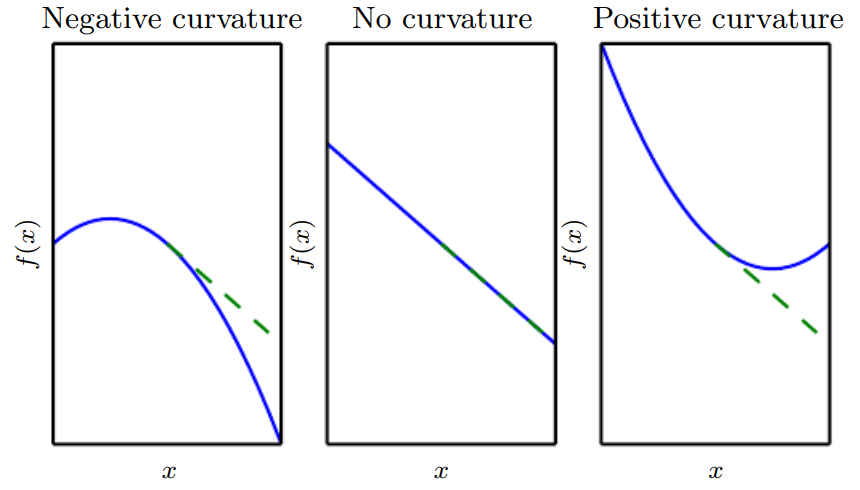                 

The **dashed line** indicates the value of the cost
function we would **expect** based on the gradient information alone as we make a gradient
step downhill.                                                             
In the case of **negative** curvature, the cost function actually decreases **faster**
than the gradient predicts.                                                           
In the case of **no** curvature, the gradient predicts the decrease
**correctly**.                                               
In the case of **positive** curvature, the function decreases **slower** than expected
and eventually begins to **increase**, so steps that are too large can actually increase the
function inadvertently.

The second-order Taylor expansion of a loss function $L(θ)$ is as follows:

$L(θ+Δθ)≈L(θ)+∇L(θ)^TΔθ+\frac{1}{2}​Δθ^THΔθ$

Where

$H$ is the Hessian matrix, containing curvature information.

As we saw in week 1, the eigenvalues of the Hessian determine whether
the critical point is a local maximum, local minimum, or saddle point.

---

## 8. Vanishing/Exploding Gradient

When the computational graph is **deep**, updating the parameters during **backpropagation** becomes difficult because the gradients are computed by repeatedly multiplying derivatives across layers using the chain rule, which can lead to the **vanishing or exploding gradient** problem.

As we saw earlier, the gradient for layer $l$ is given by:

$\frac{∂J}{∂W^{(l)}}=\frac{∂J}{∂a^{(L)}}\frac{∂a^{(L)}}{∂a^{(L−1)}}⋯\frac{∂a^{(l)}}{∂W^{(l)}}$

If some of the derivatives are **less than 1**, then $\frac{∂J}{∂W^{(l)}}$ tends toward 0, causing the gradients to **vanish**.

If they are **greater than 1**, then $\frac{∂J}{∂W^{(l)}}$ grows exponentially, causing the gradients to **explode**.

We can also check this using **eigenvalues**:

For an $L$-layer network:

$J=J_{L}J_{L−1}⋯J_1$

If eigenvalues are small: ${∣J_i∣}<{1}$ then $J≈0$ and gradients vanish.

If they are large: ${∣J_i∣}>{1}$ then $J→∞$ and gradients explode.

Vanishing gradients make it difficult to know which direction the parameters should move to improve
the cost function,                                    
while exploding gradients can make learning unstable.

There are some **solutions** to keep the Jacobian from shrinking or growing too much:

Other activation functions instead of sigmoid or tanh.

Weight initialization such as Xavier or He initialization.

Batch normalization

Residual connections

... .

We plot the effect of low or high gradients:

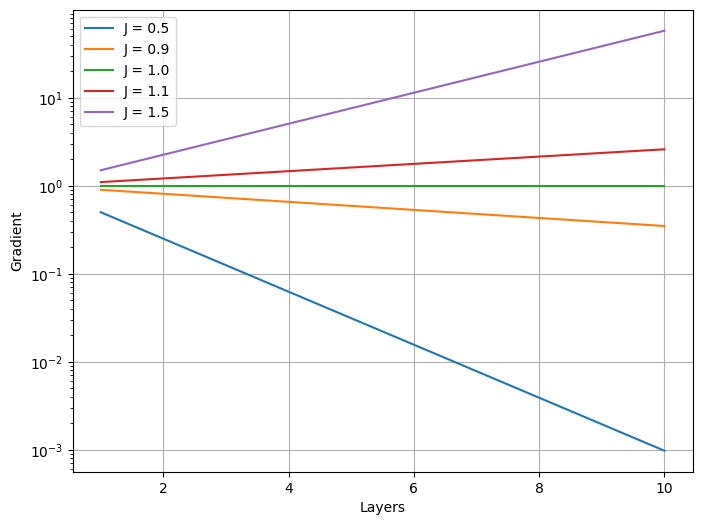

In [21]:
layers = np.arange(1, 11)
derivatives = [0.5, 0.9, 1.0, 1.1, 1.5]

plt.figure(figsize=(8, 6))
for d in derivatives:
    gradients = d ** layers
    plt.plot(layers, gradients, label=f"J = {d}")
plt.yscale("log")
plt.xlabel("Layers")
plt.ylabel("Gradient")
plt.grid(True)
plt.legend()
plt.show()

---

## 9. How To Import Our Modules

Suppose the structure of project is as follows:

```text
project/                                       
│                                             
├── main.py                                          
└── mymodule.py
```

In mymodule.py, we define the variables, functions, classes,...

In [ ]:
def add(a, b):
    return a + b

def subtract(a, b):
    return a - b

Now we call it in main.py

In [ ]:
import mymodule

mymodule.add(3,5)

or

In [ ]:
from mymodule import add

add(8,2)

If we want to import from a package, we should do the following

```text
project/
│
├── main.py
└── utils/
    ├── __init__.py
    └── helper.py
```

In helper.py

In [55]:
def hello(name):
    print(f"Hello {name}!")

Now in main.py

In [ ]:
from utils.helper import hello

hello('World')

---

---

# Week 4

Contents:

[1. Introduction to Optimization & Objective Function](#1.-Introduction-to-Optimization-&-Objective-Function)

[2. Geometry of Optimization (Loss Landscape, Curvature)](#2.-Geometry-of-Optimization-(Loss-Landscape,-Curvature))

[3. Stochastic Optimization (Batch, SGD, Mini-Batch)](#3.-Stochastic-Optimization-(Batch,-SGD,-Mini-Batch))

[4. Momentum and Nesterov Momentum](#4.-Momentum-and-Nesterov-Momentum)

[5. Learning Rate & Learning Rate Scheduling](#5.-Learning-Rate-&-Learning-Rate-Scheduling)

[6. Convergence Analysis](#6.-Convergence-Analysis)

[7. Weight Initialization](#7.-Weight-Initialization)

[8. Normalization](#8.-Normalization)

[9. Regularization](#9.-Regularization)

[10. AdaGrad](#10.-AdaGrad)

[11. RMSProp](#11.-RMSProp)

[12. Adam](#12.-Adam)

[13. AdamW](#13.-AdamW)

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt

---

## 1. Introduction to Optimization & Objective Function

Most deep learning algorithms involve optimization of some sort.                                                           
Optimization refers to the task of either **minimizing** or **maximizing** some **function** $f(x)$ by altering $x$.                                              
We usually aim to find the best values of model parameters (like weights and biases) that minimize $f(x)$.

The function we want to minimize or maximize is called the **objective function** or criterion.                                                      
When we are minimizing it, we may also call it the cost function, loss function, or error function.                                                
In this book, they use these terms interchangeably, though some machine learning publications assign special meaning to some of these terms.

We often denote the value that minimizes or maximizes a function with a superscript $^∗$.                                       
For example, we might say     

$$
x^∗= arg min f(x)
$$

The optimization steps are as follows:

**1: Forward Propagation**                                                 
Input data passes through the network and the model produces predictions.

**2: Calculate Loss**                                                          
The prediction is compared with the true value.

For example)

Mean Squared Error (MSE): Used for predicting continuous numbers (regression).
$$
MSE=\frac{1}{n}∑_{i=1}^{n}(y_i−\hat{y}_i)^2
$$
where:                                                    
$y_i$ = actual output                                              
$\hat{y}_i$ = predicted output

Categorical Cross Entropy: Used for categorizing things (classification).
$$
J=−∑_{i=1}^{n}y_{i}log(\hat{y}_i)
$$
**3: Compute Gradients**                                     
The optimizer calculates how much each parameter contributes to the error.                                         
This is done using backpropagation.                                                     
Gradient:    
$$
∇J(W)  
$$
shows the direction of maximum increase of loss.

**4: Update Parameters**                                                     
Weights are updated using gradient descent algorithm:                                        
$$
W_{new​}=W_{old}​−η∇J(W)
$$
where:                                                         
$η$ = learning rate                                              
$∇J(W)$ = gradient of loss

---

## 2. Geometry of Optimization (Loss Landscape, Curvature)

Training a neural network is fundamentally an exercise in navigating a complex, high-dimensional topographical map to find the **lowest possible point**. 

The coordinates on this map are the network's **parameters** (weights and biases, denoted as $\theta$), and the elevation is the **value** of the loss function $L(\theta)$. 

Visualizing this geometry provides deep **intuition** into why neural networks train effectively, why they sometimes fail, and how modern optimization algorithms operate.

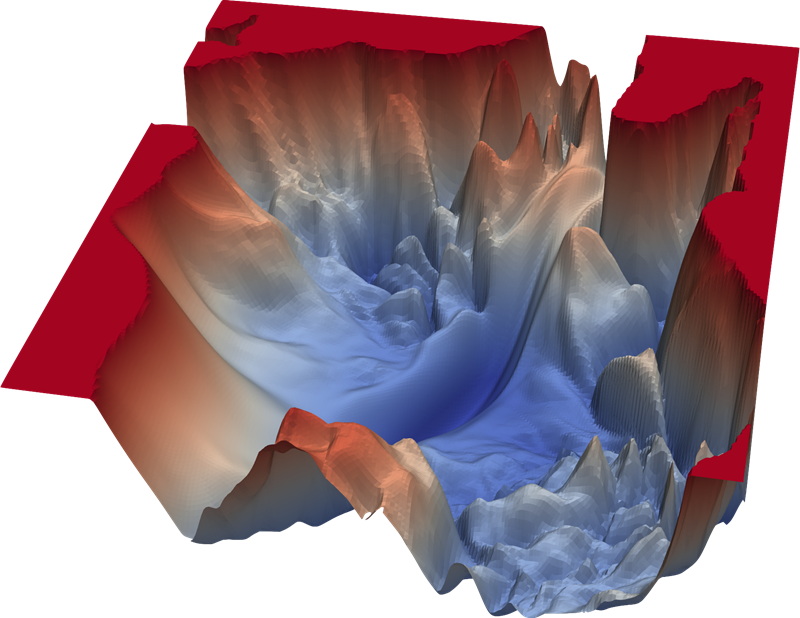

While the first derivative ($\nabla{L}$) tells the optimizer which way is down, it provides no information about the shape of the terrain. 

As we saw in the last weeks, the geometry and **curvature** of the landscape are captured by second-order derivatives, organized in the **Hessian matrix** $H$:
$$
H_{i,j} = \frac{\partial^2 {L}}{\partial \theta_i \partial \theta_j}
$$
The eigenvalues of the Hessian ($\lambda$) determine the curvature in different directions:                       

**Positive** eigenvalue ($\lambda > 0$): The landscape curves **upward**.                              
**Negative** eigenvalue ($\lambda < 0$): The landscape curves **downward**.                             
**Zero** eigenvalue ($\lambda = 0$): The landscape is perfectly **flat** in that direction.                               

Finding a minimum is not all the way, the shape of that minimum dictates how well the network will generalize to **unseen** data.                   
Because training data and real-world test data are never perfectly identical, the loss landscape shifts slightly during inference.

**Sharp Minima** has large curvature. parameters must be precise, small perturbations increase loss significantly and often poorer generalization.

**Flat Minima** has low curvature. many nearby parameter settings perform similarly, often associated with better generalization

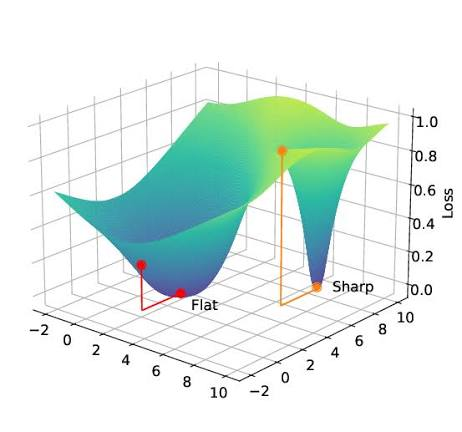

Deep networks have unusual geometry.                             
A model with billion parameters has a loss surface in a billion-dimensional space.                                
Traditional intuition from 2D optimization often fails.                               
They usually have many global-like minima, connected low-loss regions and saddle points.

---

## 3. Stochastic Optimization (Batch, SGD, Mini-Batch)

This part focuses on $J(θ)$ in the gradient descent formula to update parameters:
$$
J(θ)=\frac{1}{m}∑_{i=1}^{m}​L(x_i​,y_i​;θ)
$$
The first strategy is to compute the gradient over the **entire dataset** which is called **Batch Gradient Descent (Full Batch)**.                                 
Compute loss for all the samples, calculate average gradient then update parameters once.                                                     
It has a smooth learning curve and a stable convergence but requires high memory and is very slow for large datasets.                                 

Another approach is **Stochastic Gradient Descent (SGD)** which uses only **one training example** to compute the gradient and update parameters immediately.                                                       
It is very fast, can escape local minima and requires little memory but it has a noisy convergence and is sensitive to learning rate.                                                                         

A strategy between Full Batch and SGD is **Mini-Batch Gradient Descent**.                                                
It uses a **small group of samples (batch)** for each update. common batch sizes are $16, 32, 64, 128,... (2^k)$                                 
It is the most widely used optimization strategy for training modern deep learning models because it provides an excellent balance between computational efficiency, memory usage, and convergence stability.

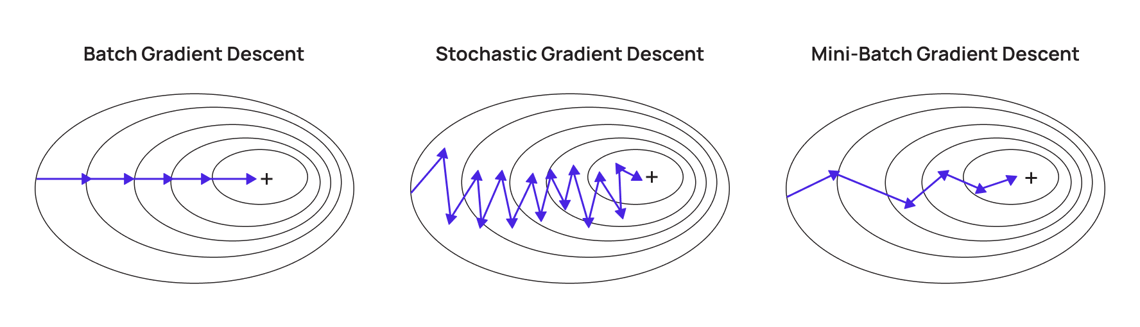

---

## 4. Momentum and Nesterov Momentum

In standard Gradient Descent, the parameters are updated using only the **current** gradient:
$$
θ_{t+1}​=θ_t​−η∇J(θ_t​)
$$
It may converge slowly, oscillate in narrow valleys and get stuck in local minima or flat regions.

**Momentum** introduces the concept of **velocity**, which accumulates information from previous gradients.                                       
Instead of following only the current gradient, the optimizer also considers the direction of **past updates**.                                       
First, we compute the velocity:
$$
v_t=βv_{t−1}+∇J(θ_t)
$$
where $β$ is momentum coefficient (typically 0.9)                                                  
Then update the parameters:
$$θ_{t+1}=θ_t−ηv_t
$$​

With momentum, oscillations are reduced, and convergence becomes much faster.

**Nesterov Momentum** improves upon classical Momentum.                                                  
Instead of computing the gradient at the current position, it first **looks ahead** to where the momentum will move the parameters.                                                               
First estimate the future position:
$$
θ_t−ηβv_{t−1}
$$
Then compute the gradient there:                                                 
$$
∇J(θ_t−ηβv_{t−1})
$$
Update the velocity:
$$
v_t=βv_{t−1}+∇J(θ_t−ηβv_{t−1})
$$
Finally:
$$
θ_{t+1}=θ_t−ηv_t
$$
It converges faster, reduces overshooting and often achieves lower training loss. 

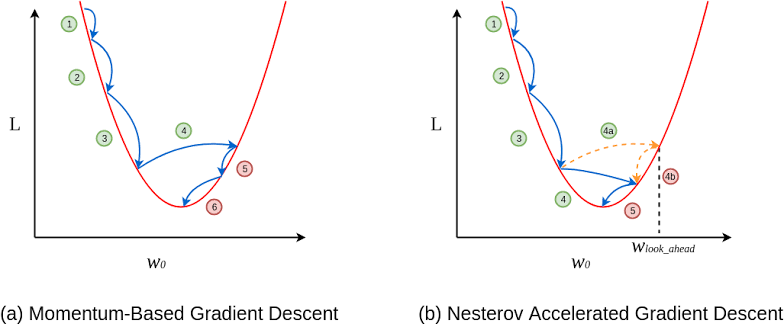

---

## 5. Learning Rate & Learning Rate Scheduling

**Learning Rate ($η$)** in Gradient Descent formula, determines **how much the model's parameters are updated** during each step.                                      
It controls the **step size** taken toward the minimum of the loss function.                                                          

Choosing the **correct** $η$ is important because it affects training speed, stability and model convergence.                                         
If $η=1$ (**too large**) then it takes very large steps, may overshoot the minimum and the loss oscillates instead of decreasing.                                 
If $η=0.000001$ (**too small**) then it takes tiny steps, training becomes very slow and may get stuck in local minima or saddle points.

**Learning Rate Scheduler** automatically **changes** $η$ during training instead of using a constant.                                             
It helps faster convergence, more stable training, reduced oscillation near the optimum and better generalization.

We introduce some types of Learning Rate Scheduling:

### 1. Step Decay                                                

$η$ decreases after a fixed number of epochs.
$$
η_t​=η_0​γ^{⌊t/s⌋}
$$
where:                                                       
$η_0$: Initial learning rate                                            
$t$ = Current epoch (or iteration)                                                   
$s$: Step size (epochs)                                                      
$γ$: Decay factor (e.g., 0.1) 
                                           
Example:                                                   
```text 
Epoch	Learning Rate
1–30	0.1
31–60	0.01
61–90	0.001
```

### 2. Exponential Decay

$η$ decreases continuously and smoothly.
$$
η_t​=η_{0}​e^{−kt}
$$
where $k$ is the decay constant.                                            
It is more gradual than Step Decay.

### 3. Polynomial Decay

It decreases according to a polynomial function.
$$
η_t​=η_{0}​(1−\frac{t}{T}​)^p
$$
where:                                                    
$T$: Total training steps                                  
$p$: Polynomial power                               

### 4. ReduceLROnPlateau

Instead of reducing η at fixed epochs, it monitors a performance metric.

Example:

If the validation loss does not improve for 10 epochs:

η = η × 0.1

It automatically adapts to training progress and there is no need to manually choose decay epochs.

### 5. Cosine Annealing

Another popular method is Cosine Annealing.
$$
η_{t}=η_{min}+\frac{1}{2}(η_{max}−η_{min})(1+cos(\frac{tπ}{T}))
$$
It starts high, gradually decreases following a cosine curve then ends with a very small learning rate.                                  
It has smooth convergence. Often achieves better accuracy than Step Decay.

Used in:

ResNet                                    
EfficientNet                                                                         
Vision Transformers                          
Large Language Models                      

Now we plot them:

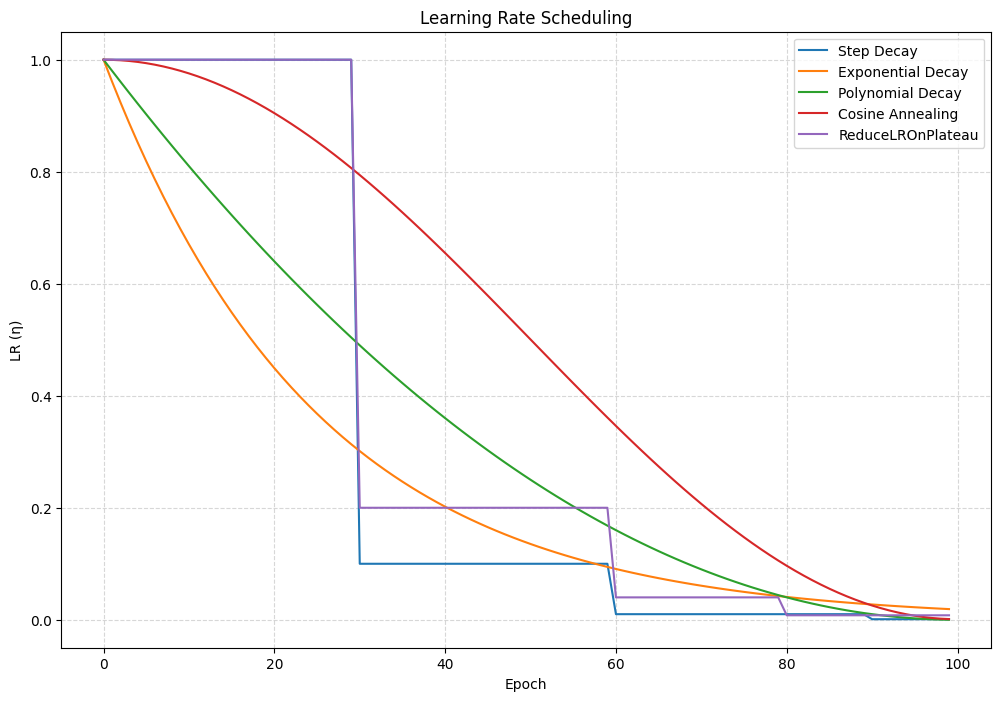

In [43]:
# Parameters
epochs = 100
t = np.arange(epochs)
init_lr = 1

# Step Decay
s = 30
gamma = 0.1
step_lr = init_lr * gamma ** (t // s)

# Exponential Decay
k = 0.04
exp_lr = init_lr * np.exp(-k * t)

# Polynomial Decay
p = 2
poly_lr = init_lr * (1 - t / epochs) ** p
poly_lr = np.maximum(poly_lr, 0)

# Cosine Annealing
min_lr = 0.001
cosine_lr = min_lr + 0.5 * (init_lr - min_lr) * (1 + np.cos(np.pi * t / epochs))

# ReduceLROnPlateau
plateau_lr = np.ones(epochs) * init_lr
plateaus = [30, 60, 80]
current_lr = init_lr
start = 0

for p in plateaus:
    plateau_lr[start:p] = current_lr
    current_lr *= 0.2
    start = p

plateau_lr[start:] = current_lr

# Plot
plt.figure(figsize=(12, 8))

plt.plot(t, step_lr, label='Step Decay')
plt.plot(t, exp_lr, label='Exponential Decay')
plt.plot(t, poly_lr, label='Polynomial Decay')
plt.plot(t, cosine_lr, label='Cosine Annealing')
plt.plot(t, plateau_lr, label='ReduceLROnPlateau')

plt.title("Learning Rate Scheduling")
plt.xlabel("Epoch")
plt.ylabel("LR (η)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

---

## 6. Convergence Analysis

Deep networks are generally **non-convex** and optimization algorithms usually aim to reach a **stationary point** rather than guaranteeing convergence to the global optimum. Therefore, reaching low training and validation loss is good enough.

An optimization algorithm is said to **converge** if its parameter sequence approaches a limiting point.                                      
It is often detected when the change in the loss becomes **very small**:
$$
∣L(θ_{t+1})−L(θ_t)∣ < ε
$$
It is possible that an algorithm reaches a stationary point but how **fast** it converges is so important.

We saw that in Gradient Descent, the convergence behavior depends on the Learning Rate and properties of the objective function.

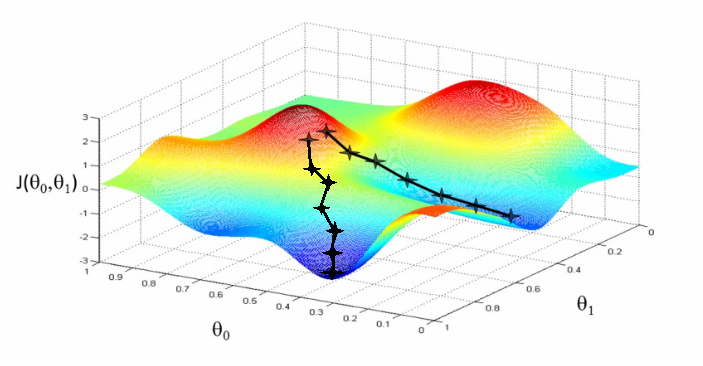

---

## 7. Weight Initialization

We know that to update paramters like weights we have the following formula:
$$
W_{t+1}​=W_t​−η\frac{∂L}{∂W}​
$$
The starting point $W_0$ strongly affects convergence speed, stability of training and the ability to escape poor regions.

What happens if we initialize all weights as **zero**?

Suppose a layer has:
$$
z=Wx+b
$$
If all $W=0$ then all neurons produce the same output:
$$
z_1=z_2=...=z_n
$$
During backpropagation:
$$
\frac{∂L}{∂W_1}=\frac{∂L}{∂W_2}=...
$$
All neurons receive the **same update**.                                               
Therefore neurons become **identical** and network can't learn **diverse** features.

A simple idea is that the weights have Normal or Uniform distribution.
$$W∼N(0,σ^2)$$
or 
$$W∼U(−a,a)$$
The problem is that if weights are too large → gradients explode, too small → gradients vanish.

Now we introduce some methods that have different variance ($σ^2$) or bound ($a$):

### 1. Xavier/Glorot Initialization

Proposed for networks using tanh, sigmoid and linear activations.

The idea is to keep variance of activations constant.

For a layer with:

$n_{in}$: number of input neurons                                    
$n_{out}$: number of output neurons

The variance of Normal is:
$$
Var(W)=\frac{2}{n_{in}+n_{out}}
$$
and the bound of Uniform is:
$$
a=\sqrt{\frac{6}{n_{in}+n_{out}}}
$$

### 2. He/Kaiming Initialization

Is suitable for:
$$
ReLU(x)=max(0,x)
$$
because ReLU removes half of the activations.

Xavier assumes:
$$
Var(input)=Var(output)
$$
but ReLU changes variance.

He assumes the variance as follows:
$$
Var(W)=\frac{2}{n_{in}}
$$

### 3. LeCun Initialization

Used mainly with SELU activation or self-normalizing networks.

Formula:
$$
Var(W)=\frac{1}{n_{in}}
$$

In summary, we have the following table:

```text
 Method | Activation Functions | Variance
------------------------------------------
 Glorot |    Tanh, Sigmoid     | 1/n_avg
------------------------------------------
   He   |   Relu & variants    | 2/n_in
------------------------------------------
 LeCun  |         Selu         | 1/n_in
```

---

## 8. Normalization

In a network, the output of one layer becomes the input of the next:
$$
x^{(l+1)}=f(W^{(l)}x^{(l)}+b^{(l)})
$$
As the weights are updated during training, the distribution of $x^{(l)}$ also changes. This problem is called **Internal Covariate Shift**.

This leads to slow convergence, unstable training and more sensitive to learning rate.

One solution is to normalize the **entire input data**.

Suppose we have data:
$$
x_1,x_2,…,x_n
$$
Compute the mean:
$$
μ=\frac{1}{n}∑_{i=1}^{n}x_i
$$
and the variance:
$$
σ^2=\frac{1}{n}∑_{i=1}^{n}(x_i−μ)^2$$
Then normalize each value:
$$
\hat{x}_i=\frac{x_i−μ}{\sqrt{σ^{2}+ϵ}}
$$
where ϵ is a small constant added for numerical stability.

After normalization,
$$
E(\hat{x})≈0,
$$
and
$$
Var(\hat{x})≈1
$$
The problem of the above method is that in deep networks, the distribution of activations in hidden layers changes after every weight update.                      
Normalizing only the original input data does not fix this, because hidden layer outputs are still changing during training.

### Batch Normalization (BatchNorm)

Instead of normalizing the entire dataset, BatchNorm normalizes each **mini-batch** independently.

For a mini-batch
$$
B={x_1,x_2,…,x_m}
$$
the batch mean is
$$
μ_B=\frac{1}{m}∑_{i=1}^{m}x_i
$$
and the batch variance is
$$
σ_{B}^{2}=\frac{1}{m}∑_{i=1}^{m}(x_i−μ_B)^2$$
Normalization is performed as
$$
\hat{x}_i=\frac{x_i−μ_B}{\sqrt{σ_{B}^{2}+ϵ}}
$$
Normalization may remove useful information about the data so BatchNorm needs learnable Scaling (γ) and shifting (β) parameters:
$$
y=γ\hat{x}+β
$$
BatchNorm is used in fully connected and CNN.

### Layer Normalization (LayerNorm)

BatchNorm depends on the batch size, which can be problematic for small batches or sequential models.

LayerNorm solves this by normalizing across the **features of a single sample**.

For a feature vector
$$
x=(x_1,x_2,…,x_d),
$$
the mean is
$$
μ=\frac{1}{d}∑_{i=1}^{d}x_i
$$
and the variance is
$$
σ^{2}=\frac{1}{d}∑_{i=1}^{d}(x_i−μ)^2
$$
Normalization becomes
$$
\hat{x}_i=\frac{x_i−μ_B}{\sqrt{σ_{B}^{2}+ϵ}}
$$
LayerNorm has applications in Transformers, RNN and NLP.

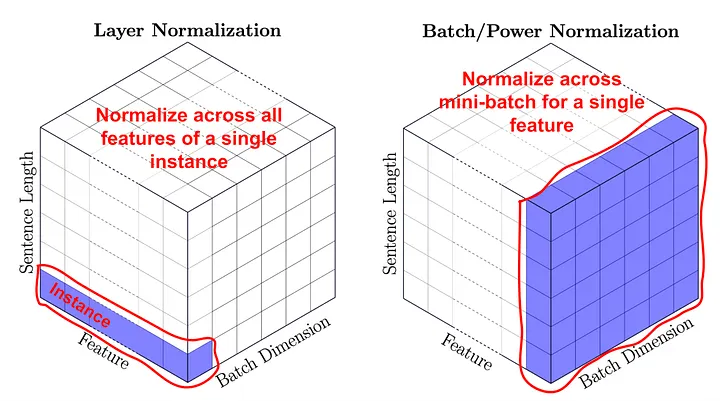

---

## 9. Regularization

Regularization is a collection of techniques used to prevent overfitting and improve a model's generalization performance.                               
It **constrains** the model so that it learns the underlying patterns in the data rather than memorizing noise or training examples.

With regularization, a **penalty term** is added to the optimization problem:
$$
\min L(θ)+λΩ(θ)
$$
where:                                   
$Ω(θ)$: Regularization term                                             
$λ$: Regularization strength (hyperparameter)

Some approches are as follows:

### 1. $L^2$ Regularization

One of the simplest and most common kinds of parameter norm penalty is the $L^2$ regularization commonly known as **weight decay**.

This strategy adds a regularization term $Ω(w)=\frac{1}{2}||w||_2^2$ to the objective function:
$$
J(w)=L(w)+\frac{λ}{2}∑_i{​w_i^2}​
$$
To take a single gradient step to update the weights, we perform this update:
$$
w_{t+1}​=w_t​−η(∇L(w)+λw)
$$
which can be rewritten as:
$$
w_{t+1}=(1−ηλ)w_t−η∇L(w)
$$
We can see that the addition of the weight decay term has modified the learning rule to multiplicatively shrink the weight vector by a constant factor on each step, just before performing the usual gradient update.                                            
Instead of allowing very large weights, $L^2$ encourages the model to keep weights **small**, leading to smoother and more generalizable models.

### 2. $L^1$ Regularization

There are other ways to penalize the size of the model parameters.                                  
Another option is to use $L^1$ regularization.

Formally, L1 regularization on the model parameter w is defined as:
$$
Ω(w)=||w||_1=∑_{i}∣w_i∣
$$
The objective becomes:
$$
J(w)=L(w)+λ∑_{i}∣w_i∣
$$
with the corresponding gradient:
$$
∇J(w)=λsign(w)+∇L(w)
$$
where $sign(w)$ is simply the sign of $w$ applied element-wise.

So $L^1$ pushes many weights exactly to **zero** and produces a **sparse** model.                                              
It can be used for feature selection and interpret models.

### 3. Dropout

Dropout approach randomly sets neurons to **zero** with probability $p$ at each step during **training** time, which helps prevent overfitting.                                  

During **testing (inference)**, all neurons remain **active**. Therefore, we have to **scale up** active neurons (not zero) by $\frac{1}{1 - p}$ during **training**.          
Suppose a neuron's activation before dropout is $h$.                                     
The expected activation during training is
$$
E[h_{train}​]=(1−p)(\frac{h}{1−p}​)+p(0)=h,
$$
which is exactly the activation used during inference, since no neurons are dropped:
$$
h_{test}=h.
$$
This technique is called **inverted dropout**.

Dropout prevents neurons from relying too heavily on one another, forces the network to learn more robust feature representations and acts like training many different subnetworks simultaneously.

### 4. Data Augmentation

The best way to make a machine learning model generalize better is to train it on more data.                                        
Of course, in practice, the amount of data we have is limited.                              
One way to get around this problem is to **create fake data** and add it to the training set.

Common techniques for image datasets include:

Rotation                                    
Horizontal/vertical flipping                                
Random cropping                                 
Scaling                                  
Brightness and color adjustments                                       
Noise injection

For example, one image of a cat can generate multiple transformed versions, giving the model more varied examples and reducing overfitting.

### 5. Early Stopping

During training:

Training loss usually continues decreasing.
Validation loss initially decreases but may later increase.

Once validation loss starts increasing while training loss continues decreasing, the model has likely begun to **overfit**.

Example:
```text
Epoch |	Training Loss |	Validation Loss
----------------------------------------
  10  |	    0.30      |	     0.35
----------------------------------------
  20  |     0.15      |      0.20
----------------------------------------
  30  |     0.05      |      0.40
```
The best model is typically the one saved at Epoch 20, where validation performance is highest.

---

## 10. AdaGrad

We know that the learning rate ($η$) in Gradient Descent is **same** for all parameters. 

**Adagrad** (Adaptive Gradient) changes this, it uses an **adaptive** learning rate for **each parameter**.

Suppose we are processing text. The word "the" is repeated many times, but the word "Adagrad" may appear only once.

If the learning rate is constant, the word "the" will be updated so much that it dominates the model.

The word "Adagrad" is rarely seen, so it does not have enough time to learn.

Adagrad keeps a separate **memory** for each parameter:

$$
(v_t)_i​ = (v_{t-1})_i + ​g^2_t
$$

where $g_t = ∇J(θ_t)$ is the current gradient.

$v_t$ stores the **sum of the squares** of the past gradients for each parameter.

Then the learning rate (η) is divided by the square root of $v_t$, so the formula becomes​:

$$
θ_{t+1}​ = θ_t ​− \frac{η}{\sqrt{v_t ​+ ϵ}}g_t
$$

For the word "the", the denominator is large so the effective learning rate becomes small.

For the word "Adagrad", the denominator is small so the effective learning rate remains large.

The main **problem** of Adagrad, is that $v_t​$ is always positive and **accumulates** at each step (because it is a power of 2).

This means that the denominator of the fraction always grows.

Eventually, the **learning rate** becomes so small that it approaches **zero** and the model stops before it is fully trained.

---

## 11. RMSProp

We saw that $v_t$ keeps on growing without bound.

**RMSProp** (Root Mean Square Propagation) is designed to improve on AdaGrad.

It uses a **moving average of squared gradients** rather than accumulating all past squared gradients.

The formula is as follows:

$$
v_t ​= β(v_{t−1}) ​+ (1−β)g_t^2​
$$

where $β\in[0,1)$ is decay rate, commonly 0.9

To update the parameters:

$$
θ_{t+1} ​= θ_t ​− \frac{η}{\sqrt{{​v_t ​​+ ϵ}}}g_t​
$$

RMSProp converges more quickly than AdaGrad by being less aggressive on decay.

The learning rate may increase, decrease, or remains constant due to the moving average of gradients in the denominator.



---

## 12. Adam

**Adam** (Adaptive Moment Estimation) combines all these techniques into one efficient learning algorithm. 

It incorporates the benefits of RMSprop’s adaptive learning rate that allows **different rates**
for different parameters. 

Additionally, similar to AdaGrad, it also maintains **per-parameter learning rates**. 

But it differs by incorporating momentum, which helps the optimizer to not get stuck in local minima and saddle points.

The steps are as follows:

**1. First moment:** average of gradients

$$
m_{t} ​= β_{1}​m_{t−1} ​+ (1−β_{1}​)g_{t​}
$$

This captures the direction in which the gradients have generally been moving.

**2. Second moment**: average of squared gradients

$$
v_t ​= β_{2​}v_{t−1} ​+ (1−β_2​)g_t^2​
$$

This captures the magnitude/scale of recent gradients.

**3. Bias correction:**

Because $m_0$ and $v_0$ start at zero, Adam corrects their initial bias to prevent $η$ become too high:

$$
\hat{m}_t​ =​ \frac{m_t}{​​1−β_1^t}
$$

$$
\hat{v}_t​ =​ \frac{v_t}{​​1−β_2^t}
$$

**4. Parameter update:**

$$
θ_{t+1} ​= θ_t ​− \frac{η}{\sqrt{\hat{v}_t​}​ + ϵ}\hat{m}_t
$$

where typical values are: $β_1​=0.9$, $β_2​=0.999$, $ϵ=10^{-8}$

In practice, Adam tends to outperform other optimization algorithms when training deep learning models.

---

## 13. AdamW

Suppose we want to give the model a better **generalization** and prevent **overfitting**.

If weight decay is implemented by adding an L2 term to the loss, the regularization becomes **entangled** with Adam's adaptive scaling.

**AdamW** (Adam with decoupled Weight Decay) is a variant of Adam that improves **how weight decay / L2 regularization is applied**.

The idea is that it separates weight decay from the gradient-based Adam update:

$$
θ_{t+1} ​= θ_t ​− \frac{η}{\sqrt{\hat{v}_t​}​ + ϵ}\hat{m}_t - ηλθ_t
$$

or equivalently:

$$
θ_{t+1} ​= (1-ηλ)θ_t ​− \frac{η}{\sqrt{\hat{v}_t​}​ + ϵ}\hat{m}_t
$$

where λ is a weight-decay coefficient.

---

---